# 配套代码：图表排版规范演示

本文件对应「金融数据分析与建模」Part II 可视化排版章节。  
运行所有单元格，将在 `./figs/` 文件夹中生成全部演示图片。

In [2]:
# ============================================================
# 单元格 0：环境准备
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

os.makedirs('./figs', exist_ok=True)
print('figs 文件夹已就绪')

figs 文件夹已就绪


## 单元格 1：全书统一配置（复制到每个 Notebook 头部使用）

In [3]:
# ============================================================
# 全书绘图统一配置
# 适用于：Quarto OnlineBook + GitHub Pages + 未来 PDF 导出
# 环境：Windows + SimHei + Matplotlib/Seaborn
# ============================================================

# ── 1. 中文字体与负号修复
mpl.rcParams['font.family']        = 'SimHei'
mpl.rcParams['axes.unicode_minus'] = False

# ── 2. 尺寸常量（英寸）
SINGLE_FIG_SIZE = (7, 4.5)   # 单图
WIDE_FIG_SIZE   = (7, 3.5)   # 宽幅时序图
SQUARE_FIG_SIZE = (5, 5)     # 正方形图（热力图等）

# ── 3. 分辨率
DPI_SCREEN = 150
DPI_PRINT  = 300

# ── 4. 字号常量（pt）
BASE_FONT  = 11
TITLE_FONT = 12
LABEL_FONT = 10
TICK_FONT  = 9
ANNOT_FONT = 9

# ── 5. 写入 rcParams
mpl.rcParams.update({
    'figure.figsize'                : SINGLE_FIG_SIZE,
    'figure.dpi'                    : DPI_SCREEN,
    'font.size'                     : BASE_FONT,
    'axes.titlesize'                : TITLE_FONT,
    'axes.labelsize'                : LABEL_FONT,
    'xtick.labelsize'               : TICK_FONT,
    'ytick.labelsize'               : TICK_FONT,
    'legend.fontsize'               : BASE_FONT,
    'legend.title_fontsize'         : BASE_FONT,
    'figure.titlesize'              : TITLE_FONT,
    'savefig.dpi'                   : DPI_SCREEN,
    'savefig.bbox'                  : 'tight',
    'figure.constrained_layout.use' : True,
})

# ── 6. Seaborn 主题（set_theme 后需重设字体）
sns.set_theme(
    style='whitegrid',
    palette='muted',
    rc={
        'font.family'        : 'SimHei',
        'axes.unicode_minus' : False,
        'font.size'          : BASE_FONT,
        'axes.titlesize'     : TITLE_FONT,
        'axes.labelsize'     : LABEL_FONT,
    }
)

print('✅ 配置加载完毕')
print(f'   字体  : {mpl.rcParams["font.family"]}')
print(f'   图尺寸 : {mpl.rcParams["figure.figsize"]}')
print(f'   分辨率 : {mpl.rcParams["figure.dpi"]} dpi')

✅ 配置加载完毕
   字体  : ['SimHei']
   图尺寸 : [7.0, 4.5]
   分辨率 : 150.0 dpi


## 演示 1：中文字体对比（乱码 vs 正常）

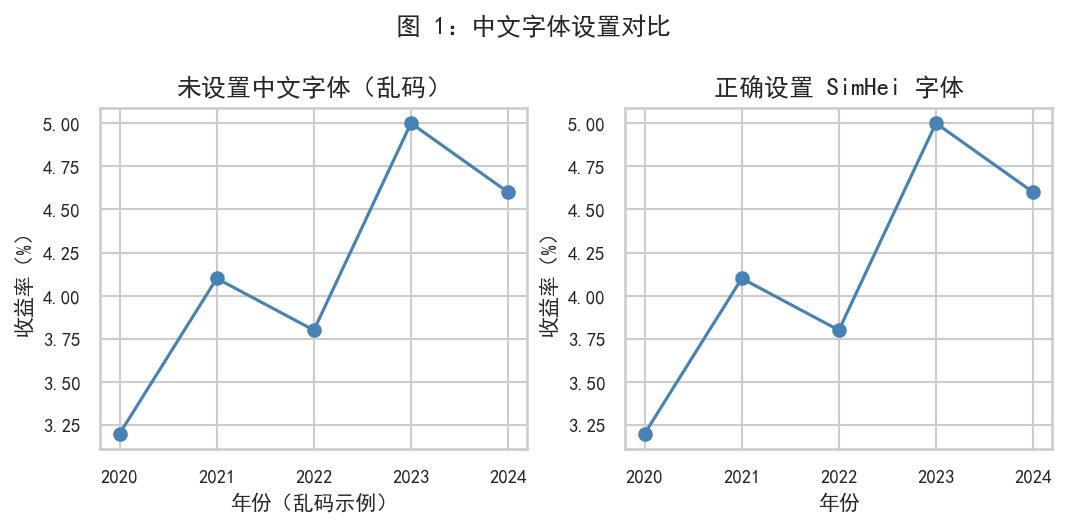

In [4]:
# 演示 1：中文乱码 vs 正常显示对比
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

x = np.arange(2020, 2025)
y = [3.2, 4.1, 3.8, 5.0, 4.6]

# 左图：模拟乱码（用默认字体显示中文）
with mpl.rc_context({'font.family': 'DejaVu Sans'}):
    axes[0].plot(x, y, marker='o', color='steelblue')
    axes[0].set_title('未设置中文字体（乱码）', fontproperties='SimHei', fontsize=TITLE_FONT)
    axes[0].set_xlabel('年份（乱码示例）', fontproperties='SimHei', fontsize=LABEL_FONT)
    axes[0].set_ylabel('收益率（%）', fontproperties='SimHei', fontsize=LABEL_FONT)
    # 故意用不支持中文的方式设置刻度标签模拟效果
    axes[0].tick_params(labelsize=TICK_FONT)

# 右图：正确设置后
axes[1].plot(x, y, marker='o', color='steelblue')
axes[1].set_title('正确设置 SimHei 字体', fontsize=TITLE_FONT)
axes[1].set_xlabel('年份', fontsize=LABEL_FONT)
axes[1].set_ylabel('收益率（%）', fontsize=LABEL_FONT)
axes[1].tick_params(labelsize=TICK_FONT)

fig.suptitle('图 1：中文字体设置对比', fontsize=TITLE_FONT, y=1.12)
fig.savefig('./figs/fig_01_chinese_font.png')
plt.show()

## 演示 2：figsize 变化对字号视觉大小的影响

C:\Users\Administrator\AppData\Local\Temp\ipykernel_12596\2632835964.py:25: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.savefig('./figs/fig_02_figsize_fontsize.png')
c:\Users\Administrator\.conda\envs\dml050\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


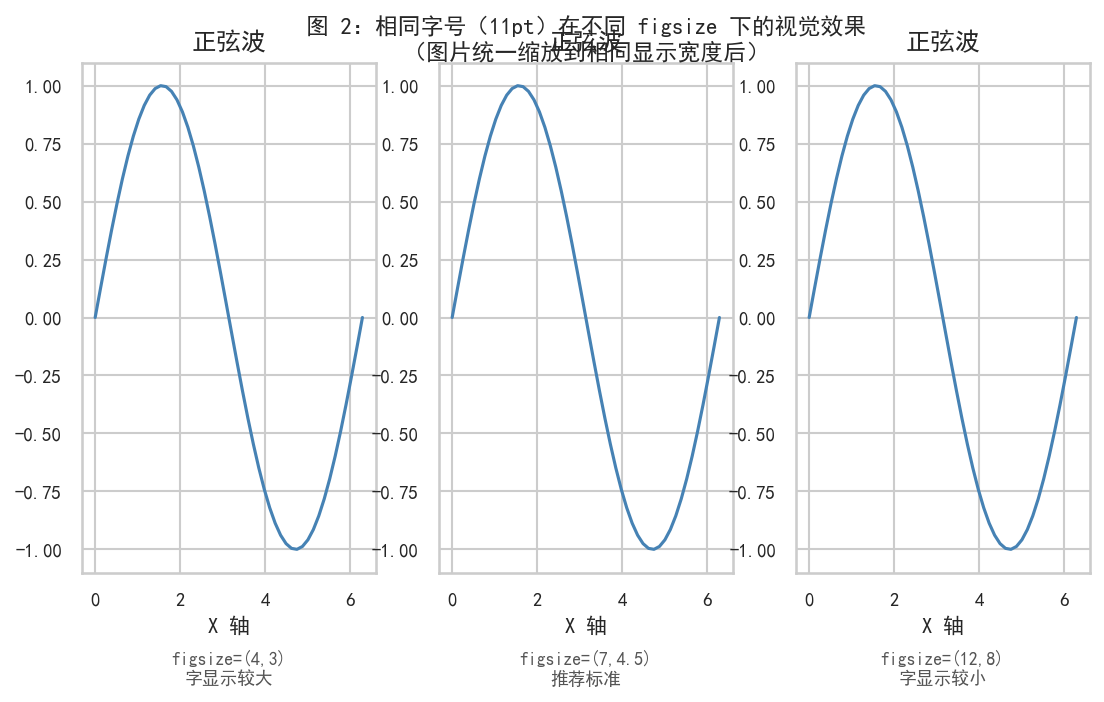

In [5]:
# 演示 2：同样的字号，不同 figsize 对视觉大小的影响
# 用一个外层 figure 并排展示三种 figsize
fig = plt.figure(figsize=(7, 4))

configs = [
    dict(rect=[0.02, 0.1, 0.28, 0.85], size=(4, 3), label='figsize=(4,3)\n字显示较大'),
    dict(rect=[0.36, 0.1, 0.28, 0.85], size=(7, 4.5), label='figsize=(7,4.5)\n推荐标准'),
    dict(rect=[0.70, 0.1, 0.28, 0.85], size=(12, 8), label='figsize=(12,8)\n字显示较小'),
]

x = np.linspace(0, 2*np.pi, 50)
y = np.sin(x)

for cfg in configs:
    ax_sub = fig.add_axes(cfg['rect'])
    ax_sub.plot(x, y, lw=1.5, color='steelblue')
    ax_sub.set_title('正弦波', fontsize=TITLE_FONT)
    ax_sub.set_xlabel('X 轴', fontsize=LABEL_FONT)
    ax_sub.tick_params(labelsize=TICK_FONT)
    ax_sub.text(0.5, -0.22, cfg['label'], transform=ax_sub.transAxes,
                ha='center', fontsize=8.5, color='#555555')

fig.suptitle('图 2：相同字号（11pt）在不同 figsize 下的视觉效果\n（图片统一缩放到相同显示宽度后）',
             fontsize=11, y=1.03)
fig.savefig('./figs/fig_02_figsize_fontsize.png')
plt.show()

## 演示 3：标准单图

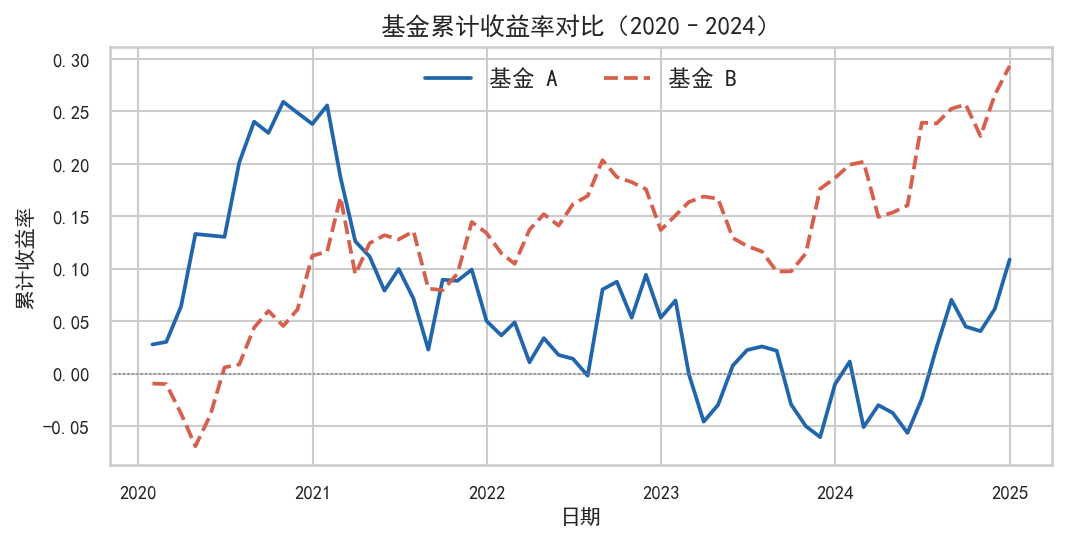

In [6]:
# 演示 3：标准单图示例（时序收益率）
np.random.seed(42)
dates = pd.date_range('2020-01-01', periods=60, freq='ME')
returns_a = np.random.normal(0.008, 0.04, 60).cumsum()
returns_b = np.random.normal(0.005, 0.03, 60).cumsum()

fig, ax = plt.subplots(figsize=WIDE_FIG_SIZE)

ax.plot(dates, returns_a, label='基金 A', lw=1.8, color='#2166ac')
ax.plot(dates, returns_b, label='基金 B', lw=1.8, color='#d6604d', linestyle='--')
ax.axhline(0, color='gray', lw=0.8, linestyle=':')

ax.set_title('基金累计收益率对比（2020–2024）', fontsize=TITLE_FONT)
ax.set_xlabel('日期', fontsize=LABEL_FONT)
ax.set_ylabel('累计收益率', fontsize=LABEL_FONT)
ax.tick_params(labelsize=TICK_FONT)
ax.legend(fontsize=BASE_FONT, loc='upper center', ncol=2, frameon=False)

fig.savefig('./figs/fig_03_single_timeseries.png')
plt.show()

## 演示 4：一行三列多子图

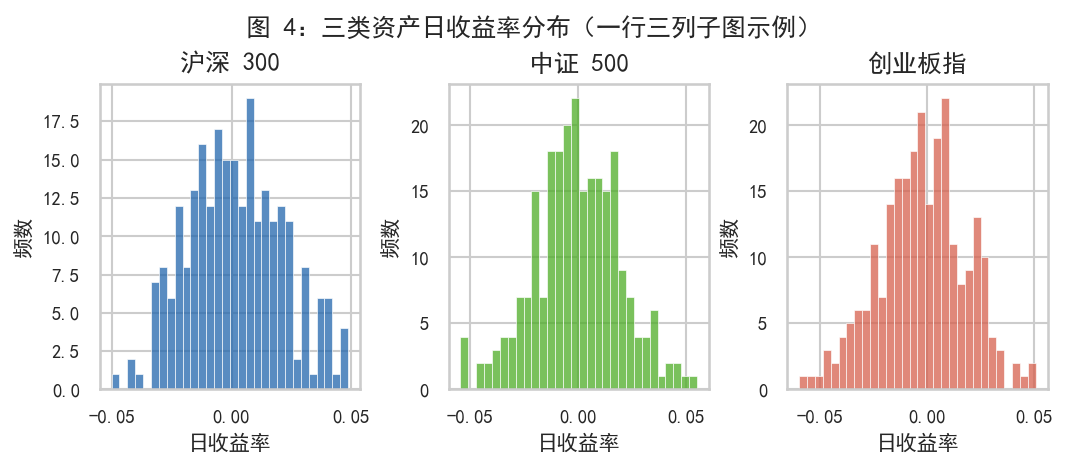

In [7]:
# 演示 4：一行三列子图（宽度固定 7 英寸，高度适当压缩）
np.random.seed(0)
assets = ['沪深 300', '中证 500', '创业板指']
colors = ['#2166ac', '#4dac26', '#d6604d']
data   = [np.random.normal(0.001, 0.02, 250) for _ in assets]

fig, axes = plt.subplots(1, 3, figsize=(7, 3.0))

for ax, asset, color, d in zip(axes, assets, colors, data):
    ax.hist(d, bins=30, color=color, alpha=0.75, edgecolor='white', lw=0.4)
    ax.set_title(asset, fontsize=TITLE_FONT)
    ax.set_xlabel('日收益率', fontsize=LABEL_FONT)
    ax.set_ylabel('频数', fontsize=LABEL_FONT)
    ax.tick_params(labelsize=TICK_FONT)

fig.suptitle('图 4：三类资产日收益率分布（一行三列子图示例）',
             fontsize=TITLE_FONT)
fig.savefig('./figs/fig_04_three_subplots.png')
plt.show()

## 演示 5：Seaborn 热力图（正方形尺寸）

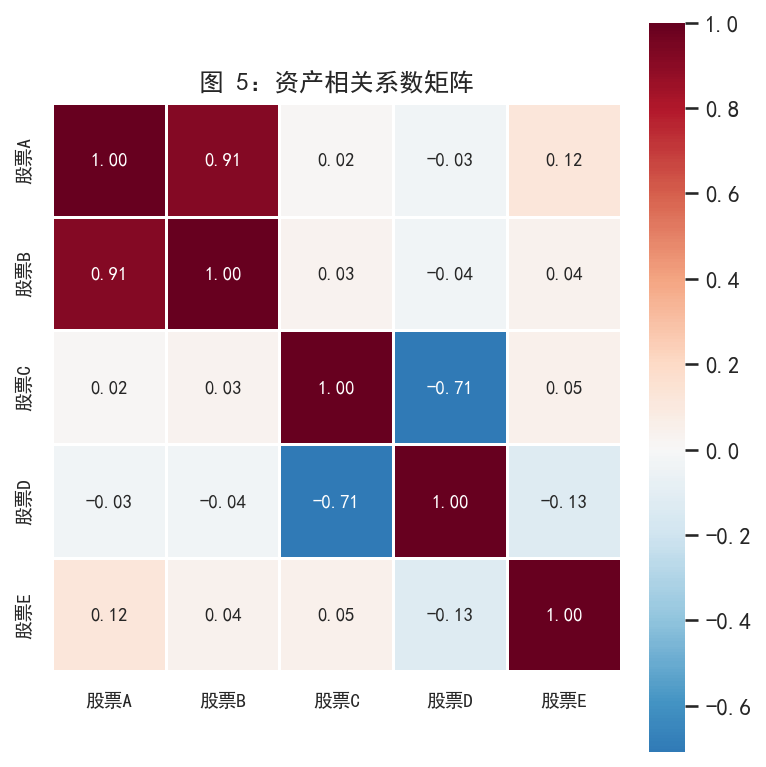

In [8]:
# 演示 5：相关系数热力图（正方形尺寸）
np.random.seed(1)
cols = ['股票A', '股票B', '股票C', '股票D', '股票E']
raw  = np.random.randn(200, 5)
raw[:, 1] = raw[:, 0] * 0.7 + raw[:, 1] * 0.3   # 制造相关性
raw[:, 3] = raw[:, 2] * -0.5 + raw[:, 3] * 0.5
df_corr = pd.DataFrame(raw, columns=cols).corr()

fig, ax = plt.subplots(figsize=SQUARE_FIG_SIZE)

sns.heatmap(
    df_corr,
    annot=True, fmt='.2f',
    annot_kws={'size': ANNOT_FONT},
    cmap='RdBu_r', center=0,
    square=True, linewidths=0.5,
    ax=ax
)
ax.set_title('图 5：资产相关系数矩阵', fontsize=TITLE_FONT)
ax.tick_params(labelsize=TICK_FONT)

fig.savefig('./figs/fig_05_heatmap.png')
plt.show()

## 演示 6：图片上下空白对比（savefig 参数的作用）

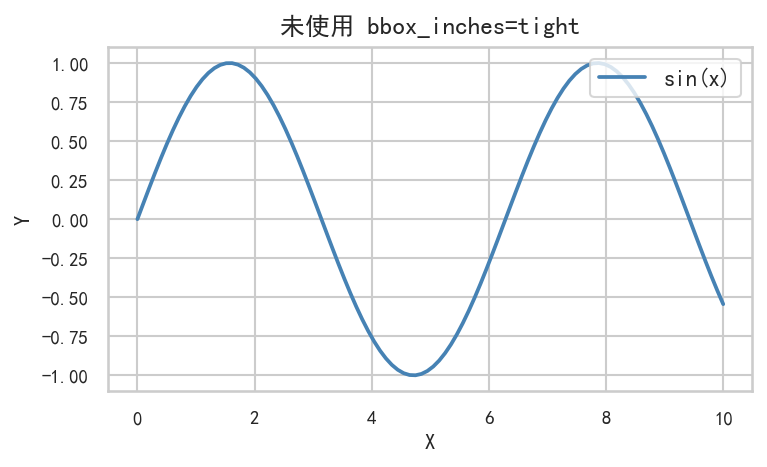

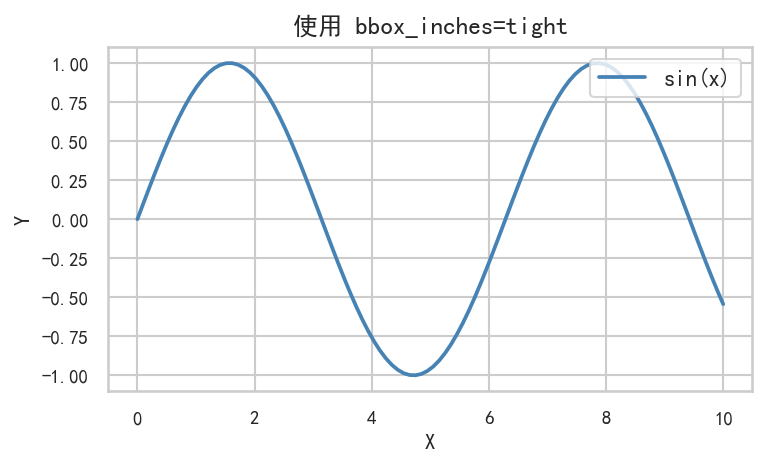

两个版本已保存到 ./figs/


In [9]:
# 演示 6：bbox_inches='tight' 前后对比
x = np.linspace(0, 10, 100)

# 保存两个版本
for tight, fname, subtitle in [
    (False, './figs/fig_06a_no_tight.png',   '未使用 bbox_inches=tight'),
    (True,  './figs/fig_06b_with_tight.png', '使用 bbox_inches=tight'),
]:
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.plot(x, np.sin(x), lw=1.8, color='steelblue', label='sin(x)')
    ax.set_title(subtitle, fontsize=TITLE_FONT)
    ax.set_xlabel('X', fontsize=LABEL_FONT)
    ax.set_ylabel('Y', fontsize=LABEL_FONT)
    ax.legend(fontsize=BASE_FONT, loc='upper right')
    ax.tick_params(labelsize=TICK_FONT)
    kw = dict(bbox_inches='tight') if tight else {}
    fig.savefig(fname, dpi=150, **kw)
    plt.show()

print('两个版本已保存到 ./figs/')

## 演示 7：constrained_layout vs tight_layout 间距效果

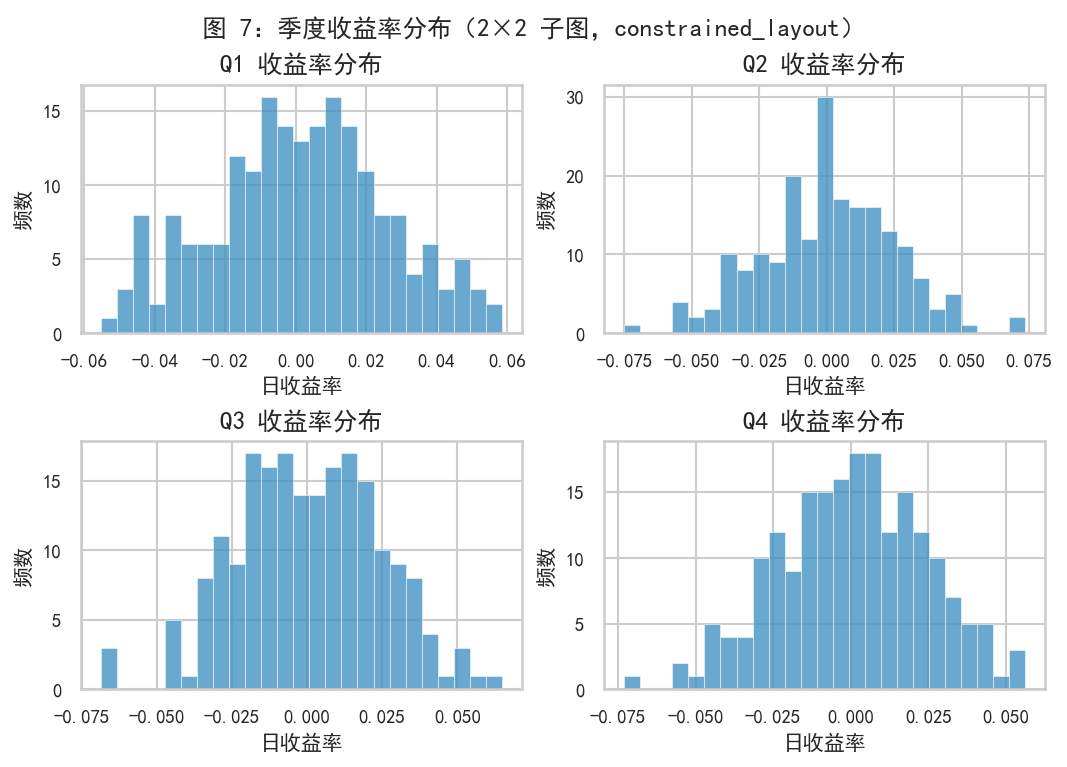

In [10]:
# 演示 7：constrained_layout 自动处理子图间距
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
titles = ['Q1 收益率分布', 'Q2 收益率分布', 'Q3 收益率分布', 'Q4 收益率分布']

np.random.seed(7)
for ax, title in zip(axes.flat, titles):
    data = np.random.normal(0.002, 0.025, 200)
    ax.hist(data, bins=25, color='#4393c3', alpha=0.8, edgecolor='white', lw=0.3)
    ax.set_title(title, fontsize=TITLE_FONT)
    ax.set_xlabel('日收益率', fontsize=LABEL_FONT)
    ax.set_ylabel('频数', fontsize=LABEL_FONT)
    ax.tick_params(labelsize=TICK_FONT)

fig.suptitle('图 7：季度收益率分布（2×2 子图，constrained_layout）',
             fontsize=TITLE_FONT)
fig.savefig('./figs/fig_07_constrained_layout.png')
plt.show()

## 生成结果汇总

In [11]:
# 汇总已生成的图片文件
figs = sorted(os.listdir('./figs'))
print(f'共生成 {len(figs)} 张图片：')
for f in figs:
    path = f'./figs/{f}'
    size_kb = os.path.getsize(path) / 1024
    print(f'  {f:45s}  {size_kb:6.1f} KB')

共生成 8 张图片：
  fig_01_chinese_font.png                          47.3 KB
  fig_02_figsize_fontsize.png                      60.4 KB
  fig_03_single_timeseries.png                     76.0 KB
  fig_04_three_subplots.png                        38.0 KB
  fig_05_heatmap.png                               50.0 KB
  fig_06a_no_tight.png                             37.9 KB
  fig_06b_with_tight.png                           37.4 KB
  fig_07_constrained_layout.png                    55.5 KB
